In [1]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from utils.dataset import load_dataset_v2
from utils.miscellaneous import create_seq_dataset_multiple_input_single_output
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from matplotlib.ticker import MultipleLocator, LogLocator
from tqdm.notebook import tqdm


In [2]:
model = ort.InferenceSession('models/model.onnx')

In [3]:
feature_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
target_name = 'outlet_flowrate(lpm)'

file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

dataset = load_dataset_v2(file_path_list)
dataset = dataset[::10]
dataset.reset_index(drop=True, inplace=True)

loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [4]:
new_dataset = dataset.copy()
new_dataset = new_dataset[new_dataset[target_name] > 1]

train_bool_list = new_dataset['test_case_iter']!=3
train_data = new_dataset[train_bool_list]
train_data.reset_index(drop=True, inplace=True)

val_bool_list = new_dataset['test_case_iter']==3
val_data = new_dataset[val_bool_list]
val_data.reset_index(drop=True, inplace=True)

In [5]:
train_dataset = train_data[feature_name_list+[target_name]].to_numpy()
val_dataset = val_data[feature_name_list+[target_name]].to_numpy()

print(train_dataset.shape, val_dataset.shape)

(132546, 2) (132546, 1)
(64001, 2) (64001, 1)
2.022491455078125
1.0112457275390625


In [6]:
seq_len = 30

train_feature, train_target = create_seq_dataset_multiple_input_single_output(data=train_dataset, seq_len=seq_len, pred_distance=0, target_idx_pos=train_dataset.shape[1])
val_feature, val_target = create_seq_dataset_multiple_input_single_output(data=val_dataset, seq_len=seq_len, pred_distance=0, target_idx_pos=val_dataset.shape[1])

train_target = np.squeeze(train_target)
val_target = np.squeeze(val_target)

print(train_feature.shape, train_target.shape)
print(val_feature.shape, val_target.shape)

print((train_feature.itemsize*train_feature.size)/(1024**2))
print((train_target.itemsize*train_target.size)/(1024**2))

creating LSTM dataset...:   0%|          | 0/132546 [00:00<?, ?it/s]

creating LSTM dataset...:   0%|          | 0/64001 [00:00<?, ?it/s]

(132517, 30, 2) (132517,)
(63972, 30, 2) (63972,)
60.661468505859375
1.0110244750976562


In [7]:
train_feature = train_feature.astype(np.float32)
train_target = train_target.astype(np.float32)

time_list = []
train_pred = []

for input_data in tqdm(train_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    train_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/132517 [00:00<?, ?it/s]

Average inference time per data sequence: 2.384 mile seconds


In [9]:
val_feature = val_feature.astype(np.float32)
val_target = val_target.astype(np.float32)

time_list = []
val_pred = []

for input_data in tqdm(val_feature):
    t0 = time.time()
    input_data = np.expand_dims(input_data, axis=0)
    val_pred.append(np.squeeze(model.run(output_names=None, input_feed={'input': input_data})).item())
    time_list.append(time.time() - t0)

time_arr = np.array(time_list)*1000
print('Average inference time per data sequence: {:.3f} mile seconds'.format(np.mean(time_arr)))

  0%|          | 0/63972 [00:00<?, ?it/s]

Average inference time per data sequence: 2.254 mile seconds


In [12]:
df = pd.DataFrame(time_arr, columns=['onnx_inference_time(ms)'])
df.to_csv('result/onnx_inference_time.csv', index=False)

In [13]:
print(r2_score(train_target_scaled, train_pred_scaled), r2_score(val_target_scaled, val_pred_scaled))
print(mean_absolute_error(train_target_scaled, train_pred_scaled), mean_absolute_error(val_target_scaled, val_pred_scaled))
print(mean_absolute_percentage_error(train_target_scaled, train_pred_scaled), mean_absolute_percentage_error(val_target_scaled, val_pred_scaled))

0.946277099185426 0.9449715551006418
78.84656094491305 83.39392127495046
0.25460279650829315 0.2738938824796854


In [14]:
val_abs_error = np.abs(val_target_scaled-val_pred_scaled)
val_rela_error = (val_abs_error / val_target_scaled)*100

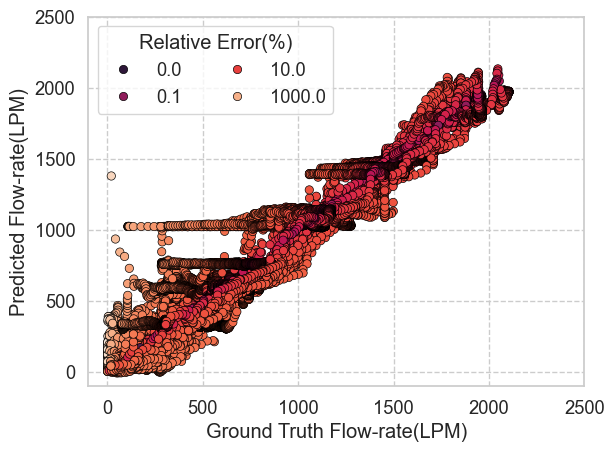

In [29]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

axis = sns.scatterplot(x=val_target_scaled, y=val_pred_scaled, edgecolor='black', hue=val_rela_error, hue_norm=colors.LogNorm(), palette="rocket")

plt.xlim(-100, 2500)
plt.xlabel('Ground Truth Flow-rate(LPM)')

plt.ylim(-100, 2500)
plt.ylabel('Predicted Flow-rate(LPM)')

plt.legend(title='Relative Error(%)', ncol=2)

legend = axis.get_legend()
labels = legend.get_texts()

for text_obj in labels:
    text = text_obj.get_text()
    corrected_string = text.replace('−', '-')
    numeric_value = float(corrected_string)
    text_obj.set_text(f'{numeric_value:0.1f}')

In [30]:
print(val_target_scaled.max())
val_data_sliced = val_data[29:]
val_data_sliced.reset_index(drop=True, inplace=True)

flow_range = np.array(range(0, int(val_target_scaled.max())+100, 100))

val_result_df = pd.DataFrame({'Ground Truth Flow Rate(LPM)': val_target_scaled, 'Predicted Flow Rate(LPM)': val_pred_scaled, 'Absolute Error(LPM)': val_abs_error, 'Relative Error(%)': val_rela_error})
val_result_df = pd.concat([val_data_sliced, val_result_df], axis=1)

refine_val_result = []

for idx in range(len(flow_range)-1):
    flow_df = val_result_df[(val_result_df['Ground Truth Flow Rate(LPM)'] >= flow_range[idx]) & (val_result_df['Predicted Flow Rate(LPM)'] < flow_range[idx+1])]
    flow_df.reset_index(drop=True, inplace=True)
    refine_val_result.append(flow_df)

flow_result = []

for flow in refine_val_result:
    flow_result.append([flow['Relative Error(%)'].mean(), flow['Relative Error(%)'].std(), flow['Absolute Error(LPM)'].mean(), flow['Absolute Error(LPM)'].std()])

flow_result = np.array(flow_result)
flow_result = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Std Relative Error(%)', 'Mean Absolute Error(LPM)', 'Std Absolute Error(LPM)'])

2105.28


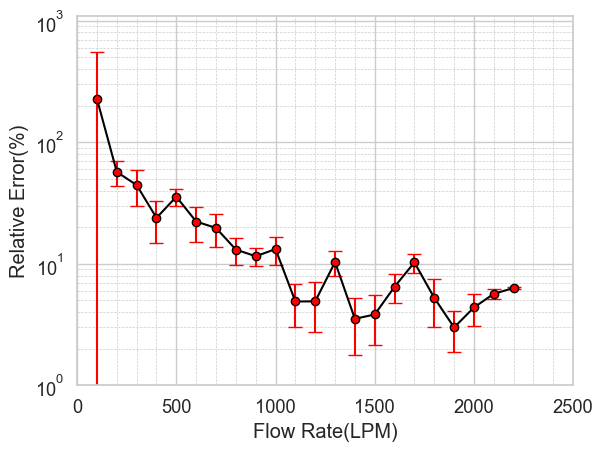

In [31]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.errorbar(flow_result['Flow Rate(LPM)'], flow_result['Mean Relative Error(%)'], yerr=flow_result['Std Relative Error(%)']/2,
             marker='o', markeredgecolor='black', markerfacecolor='red', capsize=5, color='black', ecolor='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.xlim(0, 2500)
plt.xlabel('Flow Rate(LPM)')

plt.ylim(1, 1100)
plt.yscale('log')
plt.ylabel('Relative Error(%)')

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

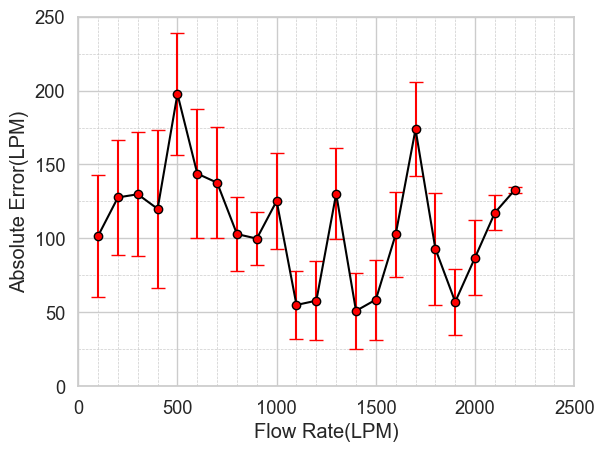

In [18]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.errorbar(flow_result['Flow Rate(LPM)'], flow_result['Mean Absolute Error(LPM)'], yerr=flow_result['Std Absolute Error(LPM)']/2,
             marker='o', markeredgecolor='black', markerfacecolor='red', capsize=5, color='black', ecolor='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.xlim(0, 2500)
plt.xlabel('Flow Rate(LPM)')

plt.ylim(0, 250)
#plt.yscale('log')
plt.ylabel('Absolute Error(LPM)')

#plt.gca().yaxis.set_major_locator(LogLocator(base=10))
plt.gca().yaxis.set_minor_locator(MultipleLocator(25))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

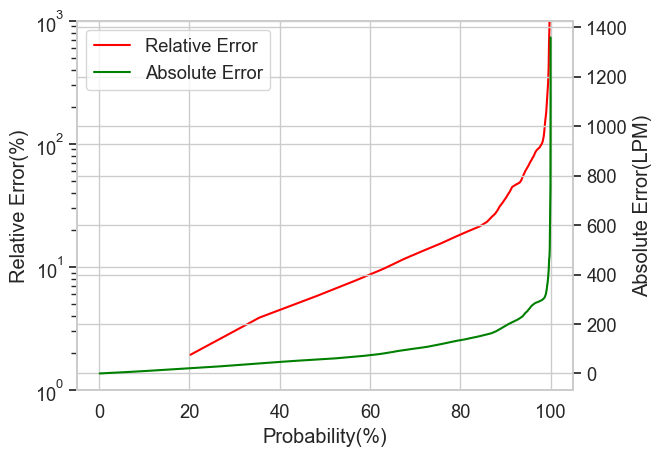

In [19]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid')

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

rela_error_hist = np.histogram(val_rela_error, bins=10000)
cum_rela_error_hist = np.cumsum(rela_error_hist[0])
cum_rela_error_hist = cum_rela_error_hist/np.max(cum_rela_error_hist)

abs_error_hist = np.histogram(val_abs_error, bins=10000)
cum_abs_error_hist = np.cumsum(abs_error_hist[0])
cum_abs_error_hist = cum_abs_error_hist/np.max(cum_abs_error_hist)

sns.lineplot(x=cum_rela_error_hist*100, y=rela_error_hist[1][1:], ax=ax1, color='red') # label 없어도 됨
ax1.set_xlabel('Probability(%)')
ax1.set_ylim(1, 1000)
ax1.set_yscale('log')
ax1.set_ylabel('Relative Error(%)')

sns.lineplot(x=cum_abs_error_hist*100, y=abs_error_hist[1][1:], ax=ax2, color='green') # label 없어도 됨
ax2.set_ylabel('Absolute Error(LPM)')

# --- 범례 생성 부분을 아래 코드로 교체 ---
# 각 축의 line 객체를 직접 선택
line1 = ax1.lines[0]
line2 = ax2.lines[0]

# 선택된 line 객체와 텍스트를 이용해 범례를 생성 (ax2에 생성)
ax2.legend(handles=[line1, line2], labels=['Relative Error', 'Absolute Error'], loc='upper left')

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.show()

In [32]:
abs_error_hist[1][1:]

array([1.37242765e-01, 2.73146993e-01, 4.09051221e-01, ...,
       1.35877181e+03, 1.35890772e+03, 1.35904362e+03], shape=(10000,))

In [20]:
flow_result_rpm_1 = []

for flow in refine_val_result:
    flow = flow[(flow['pump_speed(rpm)'] > 850) & (flow['pump_speed(rpm)'] < 950)]
    flow_result_rpm_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_rpm_1 = np.array(flow_result_rpm_1)
flow_result_rpm_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_rpm_1]),
                                 columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_rpm_2 = []

for flow in refine_val_result:
    flow = flow[(flow['pump_speed(rpm)'] > 1150) & (flow['pump_speed(rpm)'] < 1250)]
    flow_result_rpm_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_rpm_2 = np.array(flow_result_rpm_2)
flow_result_rpm_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_rpm_2]),
                                 columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_rpm_3 = []

for flow in refine_val_result:
    flow = flow[(flow['pump_speed(rpm)'] > 1450) & (flow['pump_speed(rpm)'] < 1550)]
    flow_result_rpm_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_rpm_3 = np.array(flow_result_rpm_3)
flow_result_rpm_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_rpm_3]),
                                 columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_list = [1, 500, 1000, 1500, 2000, 2500]
flow_result_list = [flow_result_rpm_1, flow_result_rpm_2, flow_result_rpm_3]

for i in range(len(flow_list)-1):
    for flow_result in flow_result_list:
        bool_idx = (flow_result['Flow Rate(LPM)'] > flow_list[i]) & (flow_result['Flow Rate(LPM)'] <= flow_list[i+1])
        print(f"rpm range: {flow_list[i]} ~ {flow_list[i+1]}", {flow_result['Mean Relative Error(%)'][bool_idx].mean()})

rpm range: 1 ~ 500 {np.float64(111.43759060823103)}
rpm range: 1 ~ 500 {np.float64(26.474791131965485)}
rpm range: 1 ~ 500 {nan}
rpm range: 500 ~ 1000 {np.float64(18.67775534855688)}
rpm range: 500 ~ 1000 {np.float64(19.557145885986376)}
rpm range: 500 ~ 1000 {np.float64(12.207104774014853)}
rpm range: 1000 ~ 1500 {np.float64(7.450950854383247)}
rpm range: 1000 ~ 1500 {np.float64(6.355862663143439)}
rpm range: 1000 ~ 1500 {np.float64(4.184344424980461)}
rpm range: 1500 ~ 2000 {np.float64(4.943400211776301)}
rpm range: 1500 ~ 2000 {np.float64(7.181982835889945)}
rpm range: 1500 ~ 2000 {np.float64(4.841364202046146)}
rpm range: 2000 ~ 2500 {np.float64(6.464250647716999)}
rpm range: 2000 ~ 2500 {np.float64(7.233571516960417)}
rpm range: 2000 ~ 2500 {np.float64(5.978122327541682)}


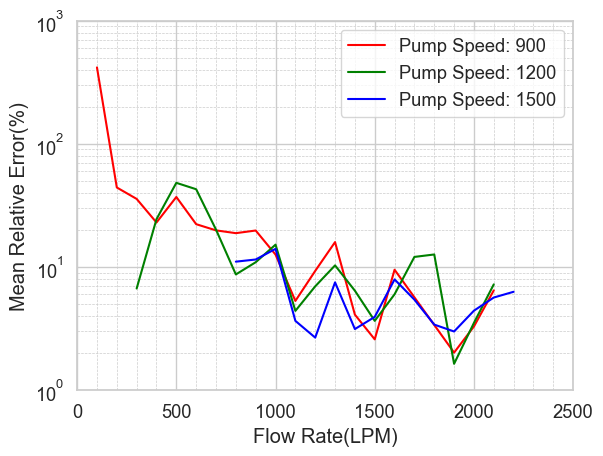

In [21]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_rpm_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Pump Speed: 900')
sns.lineplot(data=flow_result_rpm_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Pump Speed: 1200')
sns.lineplot(data=flow_result_rpm_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Pump Speed: 1500')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 1000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [22]:
flow_result_nozzle_dia_1 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_dia(mm)'] ==12.0]
    flow_result_nozzle_dia_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_dia_1 = np.array(flow_result_nozzle_dia_1)
flow_result_nozzle_dia_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_dia_1]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_dia_2 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_dia(mm)'] ==15.8]
    flow_result_nozzle_dia_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_dia_2 = np.array(flow_result_nozzle_dia_2)
flow_result_nozzle_dia_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_dia_2]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_dia_3 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_dia(mm)'] ==20.0]
    flow_result_nozzle_dia_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_dia_3 = np.array(flow_result_nozzle_dia_3)
flow_result_nozzle_dia_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_dia_3]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_list = [1, 500, 1000, 1500, 2000, 2500]
flow_result_list = [flow_result_nozzle_dia_1, flow_result_nozzle_dia_2, flow_result_nozzle_dia_3]

for i in range(len(flow_list)-1):
    for flow_result in flow_result_list:
        bool_idx = (flow_result['Flow Rate(LPM)'] > flow_list[i]) & (flow_result['Flow Rate(LPM)'] <= flow_list[i+1])
        print(f"rpm range: {flow_list[i]} ~ {flow_list[i+1]}", {flow_result['Mean Relative Error(%)'][bool_idx].mean()})

rpm range: 1 ~ 500 {np.float64(60.27186062760636)}
rpm range: 1 ~ 500 {np.float64(82.54729991693458)}
rpm range: 1 ~ 500 {np.float64(84.00262435531268)}
rpm range: 500 ~ 1000 {np.float64(18.854981291555703)}
rpm range: 500 ~ 1000 {np.float64(16.677952493856278)}
rpm range: 500 ~ 1000 {np.float64(22.814489764807668)}
rpm range: 1000 ~ 1500 {np.float64(7.748772690551687)}
rpm range: 1000 ~ 1500 {np.float64(6.185477205082451)}
rpm range: 1000 ~ 1500 {np.float64(4.809622847058732)}
rpm range: 1500 ~ 2000 {np.float64(5.746396333278619)}
rpm range: 1500 ~ 2000 {np.float64(9.689765383114073)}
rpm range: 1500 ~ 2000 {nan}
rpm range: 2000 ~ 2500 {np.float64(5.984673156700834)}
rpm range: 2000 ~ 2500 {nan}
rpm range: 2000 ~ 2500 {nan}


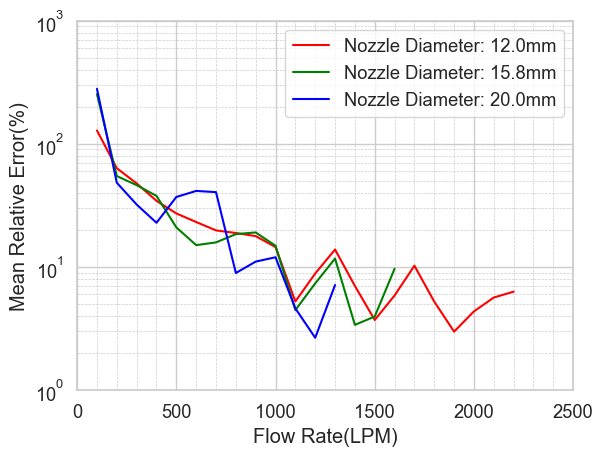

In [23]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_nozzle_dia_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Nozzle Diameter: 12.0mm')
sns.lineplot(data=flow_result_nozzle_dia_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Nozzle Diameter: 15.8mm')
sns.lineplot(data=flow_result_nozzle_dia_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Nozzle Diameter: 20.0mm')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 1000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [24]:
flow_result_nozzle_len_1 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_len(mm)'] ==12.0]
    flow_result_nozzle_len_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_len_1 = np.array(flow_result_nozzle_len_1)
flow_result_nozzle_len_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_len_1]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_len_2 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_len(mm)'] ==24.0]
    flow_result_nozzle_len_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_len_2 = np.array(flow_result_nozzle_len_2)
flow_result_nozzle_len_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_len_2]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_nozzle_len_3 = []

for flow in refine_val_result:
    flow = flow[flow['nozzle_len(mm)'] ==36.0]
    flow_result_nozzle_len_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_nozzle_len_3 = np.array(flow_result_nozzle_len_3)
flow_result_nozzle_len_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_nozzle_len_3]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_list = [1, 500, 1000, 1500, 2000, 2500]
flow_result_list = [flow_result_nozzle_len_1, flow_result_nozzle_len_2, flow_result_nozzle_len_3]

for i in range(len(flow_list)-1):
    for flow_result in flow_result_list:
        bool_idx = (flow_result['Flow Rate(LPM)'] > flow_list[i]) & (flow_result['Flow Rate(LPM)'] <= flow_list[i+1])
        print(f"rpm range: {flow_list[i]} ~ {flow_list[i+1]}", {flow_result['Mean Relative Error(%)'][bool_idx].mean()})

rpm range: 1 ~ 500 {np.float64(53.25182659207742)}
rpm range: 1 ~ 500 {np.float64(102.6040216118793)}
rpm range: 1 ~ 500 {np.float64(72.43931438678958)}
rpm range: 500 ~ 1000 {np.float64(18.197773998547824)}
rpm range: 500 ~ 1000 {np.float64(17.53122232125083)}
rpm range: 500 ~ 1000 {np.float64(9.94383229582581)}
rpm range: 1000 ~ 1500 {np.float64(7.393288956786934)}
rpm range: 1000 ~ 1500 {np.float64(3.661447266668124)}
rpm range: 1000 ~ 1500 {np.float64(4.7419325998363675)}
rpm range: 1500 ~ 2000 {np.float64(6.999402638918719)}
rpm range: 1500 ~ 2000 {np.float64(2.743593600683146)}
rpm range: 1500 ~ 2000 {np.float64(4.892419841494649)}
rpm range: 2000 ~ 2500 {np.float64(5.984673156700834)}
rpm range: 2000 ~ 2500 {nan}
rpm range: 2000 ~ 2500 {nan}


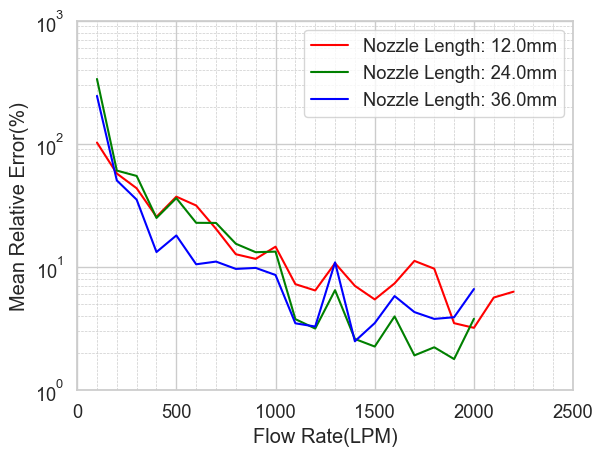

In [25]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_nozzle_len_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Nozzle Length: 12.0mm')
sns.lineplot(data=flow_result_nozzle_len_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
             label='Nozzle Length: 24.0mm')
sns.lineplot(data=flow_result_nozzle_len_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Nozzle Length: 36.0mm')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 1000)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

In [28]:
flow_result_venturi_dist_1 = []

for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==0.0]
    flow_result_venturi_dist_1.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_1 = np.array(flow_result_venturi_dist_1)
flow_result_venturi_dist_1 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_1]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_venturi_dist_2 = []

for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==15.0]
    flow_result_venturi_dist_2.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_2 = np.array(flow_result_venturi_dist_2)
flow_result_venturi_dist_2 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_2]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_venturi_dist_3 = []


for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==30.0]
    flow_result_venturi_dist_3.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_3 = np.array(flow_result_venturi_dist_3)
flow_result_venturi_dist_3 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_3]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_result_venturi_dist_4 = []


for flow in refine_val_result:
    flow = flow[flow['venturi_dist(mm)'] ==60.0]
    flow_result_venturi_dist_4.append([flow['Relative Error(%)'].mean(), flow['Absolute Error(LPM)'].mean()])

flow_result_venturi_dist_4 = np.array(flow_result_venturi_dist_4)
flow_result_venturi_dist_4 = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result_venturi_dist_4]),
                                          columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Mean Absolute Error(LPM)'])

flow_list = [1, 500, 1000, 1500, 2000, 2500]
flow_result_list = [flow_result_venturi_dist_1, flow_result_venturi_dist_3, flow_result_venturi_dist_4]

for i in range(len(flow_list)-1):
    for flow_result in flow_result_list:
        bool_idx = (flow_result['Flow Rate(LPM)'] > flow_list[i]) & (flow_result['Flow Rate(LPM)'] <= flow_list[i+1])
        print(f"rpm range: {flow_list[i]} ~ {flow_list[i+1]}", {flow_result['Mean Relative Error(%)'][bool_idx].mean()})

rpm range: 1 ~ 500 {np.float64(57.754210028054615)}
rpm range: 1 ~ 500 {np.float64(71.12559295846123)}
rpm range: 1 ~ 500 {np.float64(88.57769746436665)}
rpm range: 500 ~ 1000 {np.float64(11.716381134651005)}
rpm range: 500 ~ 1000 {np.float64(12.721834897011814)}
rpm range: 500 ~ 1000 {np.float64(19.730309076458337)}
rpm range: 1000 ~ 1500 {np.float64(3.384509815742168)}
rpm range: 1000 ~ 1500 {np.float64(4.24551572725218)}
rpm range: 1000 ~ 1500 {np.float64(7.674661431193296)}
rpm range: 1500 ~ 2000 {np.float64(1.5688502482358389)}
rpm range: 1500 ~ 2000 {np.float64(3.418250832581615)}
rpm range: 1500 ~ 2000 {np.float64(7.938374687188303)}
rpm range: 2000 ~ 2500 {nan}
rpm range: 2000 ~ 2500 {nan}
rpm range: 2000 ~ 2500 {np.float64(5.984673156700834)}


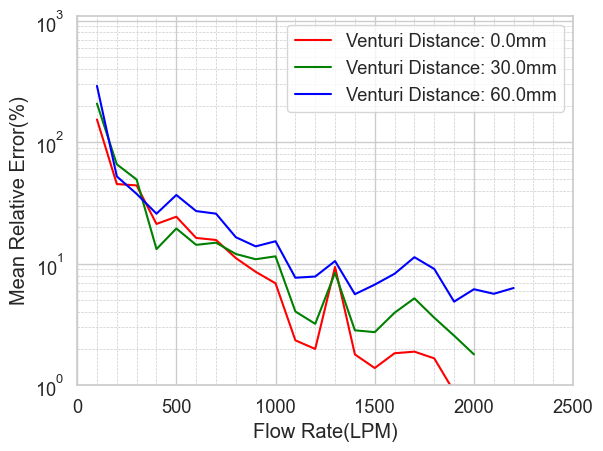

In [27]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.lineplot(data=flow_result_venturi_dist_1, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='red', marker='',
             label='Venturi Distance: 0.0mm')
# sns.lineplot(data=flow_result_venturi_dist_2, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green', marker='',
#              label='Venturi Distance: 15.0mm')
sns.lineplot(data=flow_result_venturi_dist_3, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='green',
             marker='', label='Venturi Distance: 30.0mm')
sns.lineplot(data=flow_result_venturi_dist_4, x='Flow Rate(LPM)', y='Mean Relative Error(%)', color='blue', marker='',
             label='Venturi Distance: 60.0mm')

plt.xlim(0, 2500)
plt.gca().xaxis.set_major_locator(MultipleLocator(500))
plt.gca().xaxis.set_minor_locator(MultipleLocator(100))

plt.yscale('log', base=10)
plt.ylim(1, 1100)

plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)